In [6]:
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import xgboost as xgb
import lightgbm as lgb
from sklearn.svm import SVC

In [7]:
import pandas as pd
import io

with open("original_RT_IoT2022.csv", "r", encoding="utf-8") as f:
    text = f.read()

# Remove all quotation marks
text = text.replace('"', '')

# Fix the header (remove leading comma)
lines = text.splitlines()

if lines[0].startswith(","):
    lines[0] = lines[0][1:]

text = "\n".join(lines)

# Load cleaned dataframe
df = pd.read_csv(io.StringIO(text))

print(df.shape)
print(df.columns.tolist())

(123117, 84)
['id.orig_p', 'id.resp_p', 'proto', 'service', 'flow_duration', 'fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_data_pkts_tot', 'bwd_data_pkts_tot', 'fwd_pkts_per_sec', 'bwd_pkts_per_sec', 'flow_pkts_per_sec', 'down_up_ratio', 'fwd_header_size_tot', 'fwd_header_size_min', 'fwd_header_size_max', 'bwd_header_size_tot', 'bwd_header_size_min', 'bwd_header_size_max', 'flow_FIN_flag_count', 'flow_SYN_flag_count', 'flow_RST_flag_count', 'fwd_PSH_flag_count', 'bwd_PSH_flag_count', 'flow_ACK_flag_count', 'fwd_URG_flag_count', 'bwd_URG_flag_count', 'flow_CWR_flag_count', 'flow_ECE_flag_count', 'fwd_pkts_payload.min', 'fwd_pkts_payload.max', 'fwd_pkts_payload.tot', 'fwd_pkts_payload.avg', 'fwd_pkts_payload.std', 'bwd_pkts_payload.min', 'bwd_pkts_payload.max', 'bwd_pkts_payload.tot', 'bwd_pkts_payload.avg', 'bwd_pkts_payload.std', 'flow_pkts_payload.min', 'flow_pkts_payload.max', 'flow_pkts_payload.tot', 'flow_pkts_payload.avg', 'flow_pkts_payload.std', 'fwd_iat.min', 'fwd_iat.max', 'fwd_iat.tot

In [8]:
print(df.columns.tolist())

['id.orig_p', 'id.resp_p', 'proto', 'service', 'flow_duration', 'fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_data_pkts_tot', 'bwd_data_pkts_tot', 'fwd_pkts_per_sec', 'bwd_pkts_per_sec', 'flow_pkts_per_sec', 'down_up_ratio', 'fwd_header_size_tot', 'fwd_header_size_min', 'fwd_header_size_max', 'bwd_header_size_tot', 'bwd_header_size_min', 'bwd_header_size_max', 'flow_FIN_flag_count', 'flow_SYN_flag_count', 'flow_RST_flag_count', 'fwd_PSH_flag_count', 'bwd_PSH_flag_count', 'flow_ACK_flag_count', 'fwd_URG_flag_count', 'bwd_URG_flag_count', 'flow_CWR_flag_count', 'flow_ECE_flag_count', 'fwd_pkts_payload.min', 'fwd_pkts_payload.max', 'fwd_pkts_payload.tot', 'fwd_pkts_payload.avg', 'fwd_pkts_payload.std', 'bwd_pkts_payload.min', 'bwd_pkts_payload.max', 'bwd_pkts_payload.tot', 'bwd_pkts_payload.avg', 'bwd_pkts_payload.std', 'flow_pkts_payload.min', 'flow_pkts_payload.max', 'flow_pkts_payload.tot', 'flow_pkts_payload.avg', 'flow_pkts_payload.std', 'fwd_iat.min', 'fwd_iat.max', 'fwd_iat.tot', 'fwd_iat.a

In [9]:
cols_to_drop = ["Unnamed: 0", "Flow_ID", "Source_IP", "Destination_IP",
                "Timestamp", "id.orig_p", "id.resp_p"]
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])


In [10]:
feat_cols_for_dedup = [c for c in df.columns if c != "Attack_type"]
before = len(df)
df = df.drop_duplicates(subset=feat_cols_for_dedup).reset_index(drop=True)
print(f"Rows before dedup: {before}  |  Rows after dedup: {len(df)}")

Rows before dedup: 123117  |  Rows after dedup: 18272


In [11]:
from sklearn.preprocessing import LabelEncoder

# Binary target
normal_traffic = ["Thing_Speak", "Wipro_bulb", "MQTT_Publish"]

if df["Attack_type"].dtype == object:
    normal_traffic = ["Thing_Speak", "Wipro_bulb", "MQTT_Publish"]
    df["Attack_type"] = df["Attack_type"].apply(lambda x: 0 if x in normal_traffic else 1)
    print("Converted Attack_type to binary.")
else:
    print("Attack_type is already binary/encoded — skipping to avoid corruption.")

# Encode ALL OTHER categorical columns
label_encoders = {}

for col in df.select_dtypes(include=["object"]).columns:

    if col == "Attack_type":
        continue

    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

X = df.drop(columns=["Attack_type"])
y = df["Attack_type"]

Converted Attack_type to binary.


In [12]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nUnique values in y:")
print(y.value_counts(dropna=False))

print("\nNumber of unique classes:", y.nunique())

X shape: (18272, 81)
y shape: (18272,)

Unique values in y:
Attack_type
0    11959
1     6313
Name: count, dtype: int64

Number of unique classes: 2


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain size: {len(X_train)}  |  Test size: {len(X_test)}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Train size: 14617  |  Test size: 3655


In [14]:
results = {}

print("\n--- Random Forest ---")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight="balanced")
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)
print("Test Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred, target_names=["Normal","Attack"]))
cv = cross_val_score(rf, X_train_scaled, y_train, cv=5, scoring='accuracy', n_jobs=-1)
print(f"5-Fold CV Accuracy: {cv.mean():.4f} (+/- {cv.std()*2:.4f})")
results['RF'] = dict(pred=rf_pred, probs=rf.predict_proba(X_test_scaled)[:,1], cv=cv)

print("\n--- XGBoost ---")
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred, target_names=["Normal","Attack"]))
cv = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
print(f"5-Fold CV Accuracy: {cv.mean():.4f} (+/- {cv.std()*2:.4f})")
results['XGB'] = dict(pred=xgb_pred, probs=xgb_model.predict_proba(X_test)[:,1], cv=cv)

print("\n--- LightGBM ---")
lgb_model = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.1, max_depth=5)
lgb_model.fit(X_train, y_train)
lgb_pred = lgb_model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, lgb_pred))
print(classification_report(y_test, lgb_pred, target_names=["Normal","Attack"]))
cv = cross_val_score(lgb_model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
print(f"5-Fold CV Accuracy: {cv.mean():.4f} (+/- {cv.std()*2:.4f})")
results['LGB'] = dict(pred=lgb_pred, probs=lgb_model.predict_proba(X_test)[:,1], cv=cv)

print("\n--- SVM (on balanced training subsample for tractability) ---")
train_df_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
train_df_scaled['Target'] = y_train.values
normal_train = train_df_scaled[train_df_scaled['Target'] == 0]
attack_train = train_df_scaled[train_df_scaled['Target'] == 1]
n_samples = min(len(normal_train), len(attack_train), 3000)
svm_train_data = pd.concat([
    normal_train.sample(n_samples, random_state=42),
    attack_train.sample(n_samples, random_state=42)
]).sample(frac=1, random_state=42)
X_train_svm = svm_train_data.drop(columns=['Target'])
y_train_svm = svm_train_data['Target']
svm = SVC(kernel="rbf", C=1.0, probability=True, random_state=42)
svm.fit(X_train_svm, y_train_svm)
svm_pred = svm.predict(X_test_scaled)
print("Test Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred, target_names=["Normal","Attack"]))
results['SVM'] = dict(pred=svm_pred, probs=svm.predict_proba(X_test_scaled)[:,1])



--- Random Forest ---
Test Accuracy: 0.9942544459644322
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00      2392
      Attack       0.99      0.99      0.99      1263

    accuracy                           0.99      3655
   macro avg       0.99      0.99      0.99      3655
weighted avg       0.99      0.99      0.99      3655

5-Fold CV Accuracy: 0.9915 (+/- 0.0021)

--- XGBoost ---
Test Accuracy: 0.9909712722298222
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99      2392
      Attack       0.98      0.99      0.99      1263

    accuracy                           0.99      3655
   macro avg       0.99      0.99      0.99      3655
weighted avg       0.99      0.99      0.99      3655

5-Fold CV Accuracy: 0.9904 (+/- 0.0057)

--- LightGBM ---
[LightGBM] [Info] Number of positive: 5050, number of negative: 9567
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead 

C:\Users\ADITI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2750: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


Test Accuracy: 0.9578659370725034
              precision    recall  f1-score   support

      Normal       0.98      0.96      0.97      2392
      Attack       0.92      0.96      0.94      1263

    accuracy                           0.96      3655
   macro avg       0.95      0.96      0.95      3655
weighted avg       0.96      0.96      0.96      3655



C:\Users\ADITI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2750: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [15]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score

print("="*60)
print("Support Vector Machine (Baseline)")
print("="*60)

svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

svm_pred = svm_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, svm_pred))

print("\nClassification Report:")
print(classification_report(y_test, svm_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, svm_pred))

cv_scores = cross_val_score(
    svm_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

print("\nCross Validation Accuracy:")
print(cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

Support Vector Machine (Baseline)
Accuracy: 0.9704514363885088

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      2392
           1       0.94      0.97      0.96      1263

    accuracy                           0.97      3655
   macro avg       0.96      0.97      0.97      3655
weighted avg       0.97      0.97      0.97      3655


Confusion Matrix:
[[2318   74]
 [  34 1229]]

Cross Validation Accuracy:
[0.9630643  0.97161423 0.97194663 0.96955183 0.97092029]
Mean CV Accuracy: 0.9694194540867211


In [16]:
import pandas as pd

print("="*70)
print("DETECTION ENGINE COMPARISON -- Accuracy")
print("="*70)
summary_rows = []
for name, r in results.items():
    acc = accuracy_score(y_test, r['pred'])
    summary_rows.append({'Model': name, 'Accuracy': round(acc, 4)})
acc_df = pd.DataFrame(summary_rows)
print(acc_df.to_string(index=False))

DETECTION ENGINE COMPARISON -- Accuracy
Model  Accuracy
   RF    0.9943
  XGB    0.9910
  LGB    0.9907
  SVM    0.9579


In [17]:
from sklearn.model_selection import train_test_split as tts
import numpy as np

lgb_accs = []
for seed in [1, 2, 3, 4, 5]:
    Xtr, Xte, ytr, yte = tts(X, y, test_size=0.2, random_state=seed, stratify=y)
    lgb_seed = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, verbose=-1)
    lgb_seed.fit(Xtr, ytr)
    acc = accuracy_score(yte, lgb_seed.predict(Xte))
    lgb_accs.append(acc)
    print(f"Seed {seed}: LightGBM Accuracy={acc:.4f}")

print(f"\nLightGBM stability: mean={np.mean(lgb_accs):.4f}  std={np.std(lgb_accs):.4f}")

Seed 1: LightGBM Accuracy=0.9891
Seed 2: LightGBM Accuracy=0.9921
Seed 3: LightGBM Accuracy=0.9918
Seed 4: LightGBM Accuracy=0.9940
Seed 5: LightGBM Accuracy=0.9902

LightGBM stability: mean=0.9914  std=0.0017


In [18]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

rf_param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 15, 20, None],       # None = unlimited, like your current setup
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1, class_weight="balanced"),
    param_distributions=rf_param_dist,
    n_iter=25, cv=3, scoring='accuracy', n_jobs=-1, random_state=42
)
rf_search.fit(X_train, y_train)

print("Best RF params:", rf_search.best_params_)
best_rf = rf_search.best_estimator_
rf_pred = best_rf.predict(X_test)
print("Tuned RF Test Accuracy:", accuracy_score(y_test, rf_pred))

Best RF params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
Tuned RF Test Accuracy: 0.9920656634746922


In [19]:
import xgboost as xgb

xgb_param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    xgb.XGBClassifier(eval_metric='logloss'),
    param_distributions=xgb_param_dist,
    n_iter=25, cv=3, scoring='accuracy', n_jobs=-1, random_state=42
)
xgb_search.fit(X_train, y_train)

print("Best XGBoost params:", xgb_search.best_params_)
best_xgb = xgb_search.best_estimator_
xgb_pred = best_xgb.predict(X_test)
print("Tuned XGBoost Test Accuracy:", accuracy_score(y_test, xgb_pred))

Best XGBoost params: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 9, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Tuned XGBoost Test Accuracy: 0.9934336525307798


In [20]:
from sklearn.model_selection import RandomizedSearchCV
import lightgbm as lgb

lgb_param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 7, 9, -1],          # -1 = no limit
    'num_leaves': [15, 31, 63, 127],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'min_child_samples': [5, 10, 20]
}

lgb_search = RandomizedSearchCV(
    lgb.LGBMClassifier(verbose=-1),
    param_distributions=lgb_param_dist,
    n_iter=25, cv=3, scoring='accuracy', n_jobs=-1, random_state=42
)
lgb_search.fit(X_train, y_train)

print("Best LightGBM params:", lgb_search.best_params_)
best_lgb = lgb_search.best_estimator_
lgb_pred = best_lgb.predict(X_test)
print("Tuned LightGBM Test Accuracy:", accuracy_score(y_test, lgb_pred))

Best LightGBM params: {'num_leaves': 15, 'n_estimators': 300, 'min_child_samples': 20, 'max_depth': -1, 'learning_rate': 0.2}
Tuned LightGBM Test Accuracy: 0.9958960328317373


In [21]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm_param_dist = {
    'C': [1, 10],
    'kernel': ['rbf'],
    'gamma': ['scale', 0.01]
}

svm_search = RandomizedSearchCV(
    estimator=SVC(probability=True, random_state=42),
    param_distributions=svm_param_dist,
    n_iter=4,          # Only 4 combinations
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

svm_search.fit(X_train_scaled, y_train)

print("Best Parameters:", svm_search.best_params_)

best_svm = svm_search.best_estimator_

svm_pred = best_svm.predict(X_test_scaled)

print("Tuned Accuracy:", accuracy_score(y_test, svm_pred))

Best Parameters: {'kernel': 'rbf', 'gamma': 0.01, 'C': 10}
Tuned Accuracy: 0.9770177838577291


In [22]:
import time
import joblib
import os
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

In [23]:
candidate_models = {
    "Random Forest": (best_rf, X_test),
    "XGBoost": (best_xgb, X_test),
    "LightGBM": (best_lgb, X_test),
    "SVM": (best_svm, X_test_scaled)
}

In [24]:
results = []

for name, (model, X_eval) in candidate_models.items():

    start = time.perf_counter()

    pred = model.predict(X_eval)

    latency = (time.perf_counter() - start) / len(X_eval)

    acc = accuracy_score(y_test, pred)

    macro = f1_score(y_test, pred, average="macro")

    filename = name.replace(" ", "_") + ".pkl"

    joblib.dump(model, filename)

    size = os.path.getsize(filename)/(1024*1024)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "MacroF1": macro,
        "Latency": latency,
        "ModelSize": size
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,MacroF1,Latency,ModelSize
0,Random Forest,0.992066,0.991250,0.000188,6.868249
1,XGBoost,0.993434,0.992749,0.000045,0.805511
2,LightGBM,0.995896,0.995469,0.000088,0.514698
3,SVM,0.977018,0.974743,0.000506,1.015117


In [25]:
selection = results_df.copy()

# Higher is better
selection["AccScore"] = (
    selection["Accuracy"] - selection["Accuracy"].min()
) / (
    selection["Accuracy"].max() - selection["Accuracy"].min()
)

selection["F1Score"] = (
    selection["MacroF1"] - selection["MacroF1"].min()
) / (
    selection["MacroF1"].max() - selection["MacroF1"].min()
)

# Lower latency is better
selection["LatencyScore"] = (
    selection["Latency"].max() - selection["Latency"]
) / (
    selection["Latency"].max() - selection["Latency"].min()
)

# Smaller model is better
selection["MemoryScore"] = (
    selection["ModelSize"].max() - selection["ModelSize"]
) / (
    selection["ModelSize"].max() - selection["ModelSize"].min()
)

selection["DeploymentScore"] = (
      0.40*selection["AccScore"]
    + 0.30*selection["F1Score"]
    + 0.20*selection["LatencyScore"]
    + 0.10*selection["MemoryScore"]
)

selection = selection.sort_values(
    by="DeploymentScore",
    ascending=False
)

selection

,Model,Accuracy,MacroF1,Latency,ModelSize,AccScore,F1Score,LatencyScore,MemoryScore,DeploymentScore
2,LightGBM,0.995896,0.995469,0.000088,0.514698,1.000000,1.000000,0.906985,1.000000,0.981397
1,XGBoost,0.993434,0.992749,0.000045,0.805511,0.869565,0.868772,1.000000,0.954228,0.903880
0,Random Forest,0.992066,0.991250,0.000188,6.868249,0.797101,0.796436,0.689155,0.000000,0.695602
3,SVM,0.977018,0.974743,0.000506,1.015117,0.000000,0.000000,0.000000,0.921238,0.092124


In [26]:
best_model_name = selection.iloc[0]["Model"]

model_map = {
    "Random Forest": best_rf,
    "XGBoost": best_xgb,
    "LightGBM": best_lgb,
    "SVM": best_svm
}

best_model = model_map[best_model_name]

joblib.dump(best_model, "Selected_IDPS_Model.pkl")

print("="*60)
print("AUTO MODEL SELECTOR")
print("="*60)
print("Selected Detection Engine :", best_model_name)
print("Deployment Score :", round(selection.iloc[0]["DeploymentScore"],4))
print("Model saved as Selected_IDPS_Model.pkl")
print("="*60)

AUTO MODEL SELECTOR
Selected Detection Engine : LightGBM
Deployment Score : 0.9814
Model saved as Selected_IDPS_Model.pkl


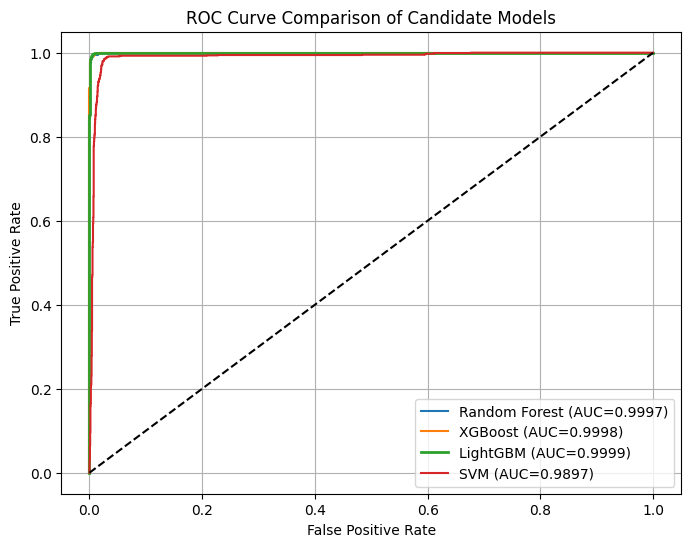

In [27]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probabilities from tuned models
rf_probs = best_rf.predict_proba(X_test)[:, 1]

xgb_probs = best_xgb.predict_proba(X_test)[:, 1]

lgb_probs = best_lgb.predict_proba(X_test)[:, 1]

svm_probs = best_svm.predict_proba(X_test_scaled)[:, 1]

# ROC Curves
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)
lgb_fpr, lgb_tpr, _ = roc_curve(y_test, lgb_probs)
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_probs)

# AUC
rf_auc = auc(rf_fpr, rf_tpr)
xgb_auc = auc(xgb_fpr, xgb_tpr)
lgb_auc = auc(lgb_fpr, lgb_tpr)
svm_auc = auc(svm_fpr, svm_tpr)

# Plot
plt.figure(figsize=(8,6))

plt.plot(rf_fpr, rf_tpr,
         label=f"Random Forest (AUC={rf_auc:.4f})")

plt.plot(xgb_fpr, xgb_tpr,
         label=f"XGBoost (AUC={xgb_auc:.4f})")

plt.plot(lgb_fpr, lgb_tpr,
         label=f"LightGBM (AUC={lgb_auc:.4f})",
         linewidth=2)

plt.plot(svm_fpr, svm_tpr,
         label=f"SVM (AUC={svm_auc:.4f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Candidate Models")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

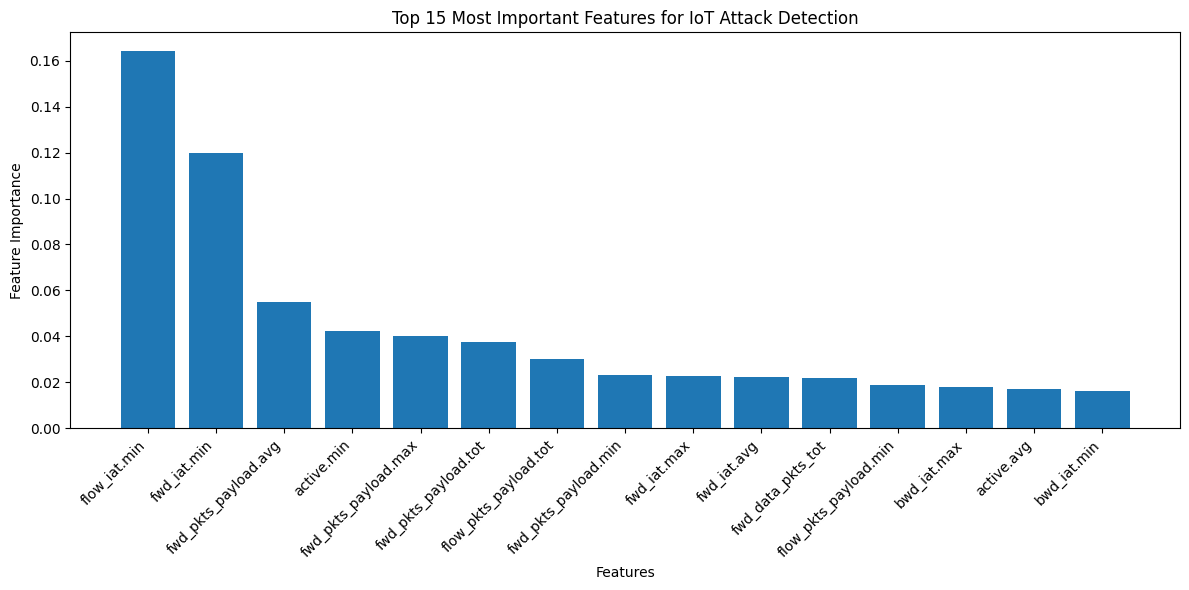

In [28]:
#############################################################
# FEATURE IMPORTANCE (Random Forest)
#############################################################

import matplotlib.pyplot as plt
import numpy as np

# Use the tuned Random Forest
importances = best_rf.feature_importances_

# Sort features
indices = np.argsort(importances)[::-1]

top_n = 15

plt.figure(figsize=(12,6))

plt.bar(
    range(top_n),
    importances[indices[:top_n]]
)

plt.xticks(
    range(top_n),
    X.columns[indices[:top_n]],
    rotation=45,
    ha="right"
)

plt.title("Top 15 Most Important Features for IoT Attack Detection")

plt.xlabel("Features")
plt.ylabel("Feature Importance")

plt.tight_layout()

plt.show()

In [29]:
with open("original_RT_IoT2022.csv","r",encoding="utf-8") as f:
    print(repr(f.readline()))

'",id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,flow_pkts_per_sec,down_up_ratio,fwd_header_size_tot,fwd_header_size_min,fwd_header_size_max,bwd_header_size_tot,bwd_header_size_min,bwd_header_size_max,flow_FIN_flag_count,flow_SYN_flag_count,flow_RST_flag_count,fwd_PSH_flag_count,bwd_PSH_flag_count,flow_ACK_flag_count,fwd_URG_flag_count,bwd_URG_flag_count,flow_CWR_flag_count,flow_ECE_flag_count,fwd_pkts_payload.min,fwd_pkts_payload.max,fwd_pkts_payload.tot,fwd_pkts_payload.avg,fwd_pkts_payload.std,bwd_pkts_payload.min,bwd_pkts_payload.max,bwd_pkts_payload.tot,bwd_pkts_payload.avg,bwd_pkts_payload.std,flow_pkts_payload.min,flow_pkts_payload.max,flow_pkts_payload.tot,flow_pkts_payload.avg,flow_pkts_payload.std,fwd_iat.min,fwd_iat.max,fwd_iat.tot,fwd_iat.avg,fwd_iat.std,bwd_iat.min,bwd_iat.max,bwd_iat.tot,bwd_iat.avg,bwd_iat.std,flow_iat.min,flow_iat.max,flow_iat.tot,flow_iat.avg,flow_iat.std,

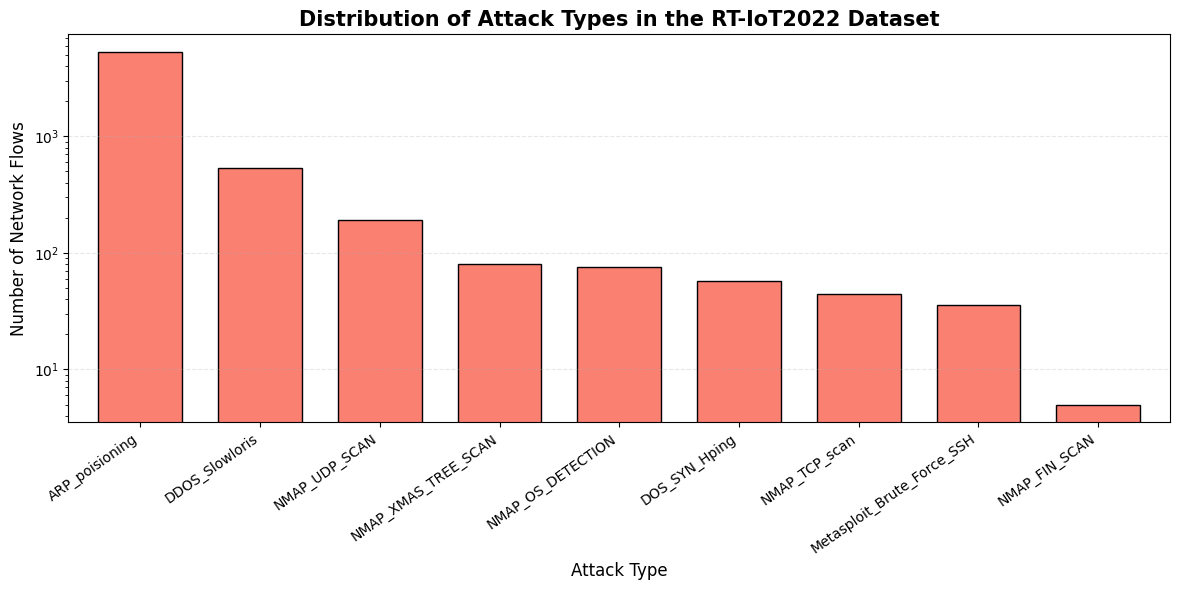

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# Load original dataset
import io

with open("original_RT_IoT2022.csv", "r", encoding="utf-8") as f:
    text = f.read()

text = text.replace('"', '')

lines = text.splitlines()

if lines[0].startswith(","):
    lines[0] = lines[0][1:]

text = "\n".join(lines)

df = pd.read_csv(io.StringIO(text))

# Remove unnecessary columns (same preprocessing as your project)
cols_to_drop = [
    "Unnamed: 0",
    "Flow_ID",
    "Source_IP",
    "Destination_IP",
    "Timestamp",
    "id.orig_p",
    "id.resp_p"
]

df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# Remove duplicate flows
feature_cols = [c for c in df.columns if c != "Attack_type"]
df = df.drop_duplicates(subset=feature_cols)

# Define normal traffic
normal_activities = [
    "Thing_Speak",
    "Wipro_bulb",
    "MQTT_Publish"
]

# Keep only attack records
attack_df = df[~df["Attack_type"].isin(normal_activities)]

# Count attacks
attack_counts = attack_df["Attack_type"].value_counts()

# Plot
plt.figure(figsize=(12,6))

attack_counts.plot(
    kind="bar",
    color="salmon",
    edgecolor="black",
    width=0.7
)

plt.title(
    "Distribution of Attack Types in the RT-IoT2022 Dataset",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Attack Type", fontsize=12)
plt.ylabel("Number of Network Flows", fontsize=12)

plt.xticks(rotation=35, ha="right")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.yscale("log")
plt.show()

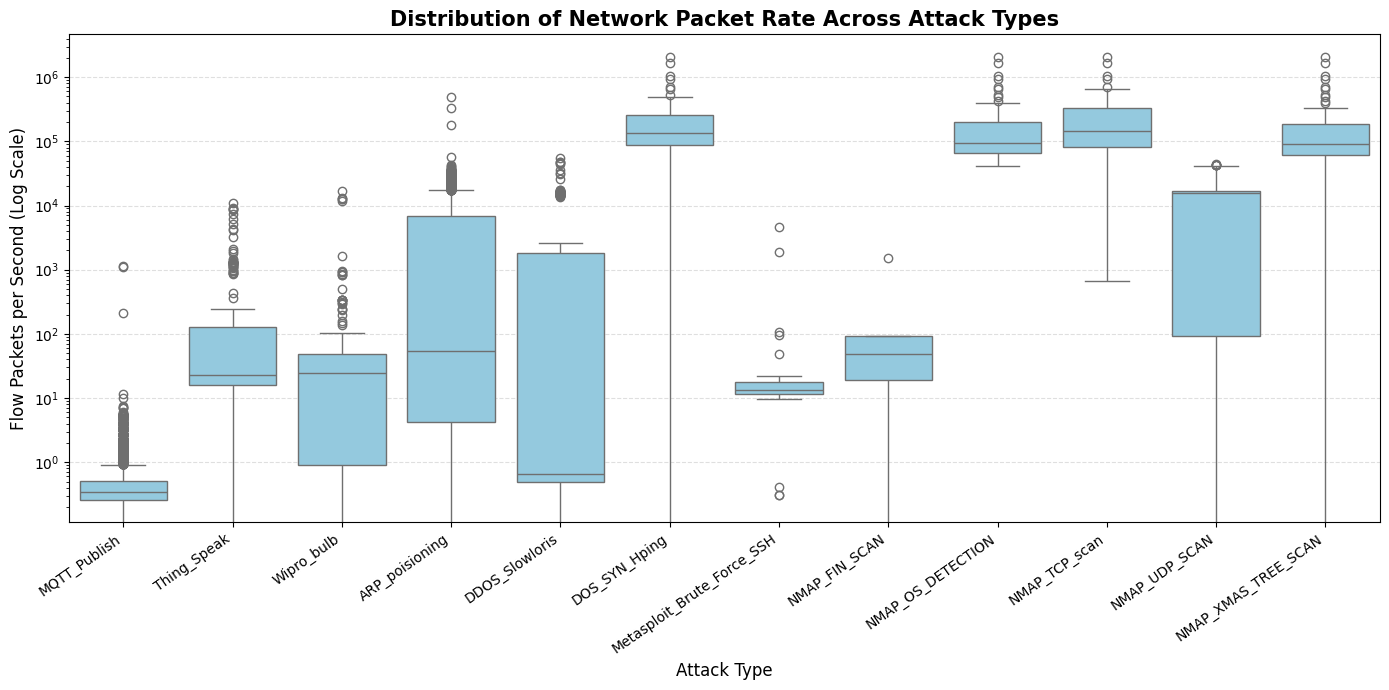

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# ======================================================
# Traffic Velocity Across Different Attack Types
# ======================================================

plt.figure(figsize=(14,7))

sns.boxplot(
    data=df,
    x="Attack_type",
    y="flow_pkts_per_sec",
    color="skyblue",
    linewidth=1
)

# Log scale because packet rates vary by several orders of magnitude
plt.yscale("log")

plt.title(
    "Distribution of Network Packet Rate Across Attack Types",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Attack Type", fontsize=12)
plt.ylabel("Flow Packets per Second (Log Scale)", fontsize=12)

plt.xticks(rotation=35, ha="right")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

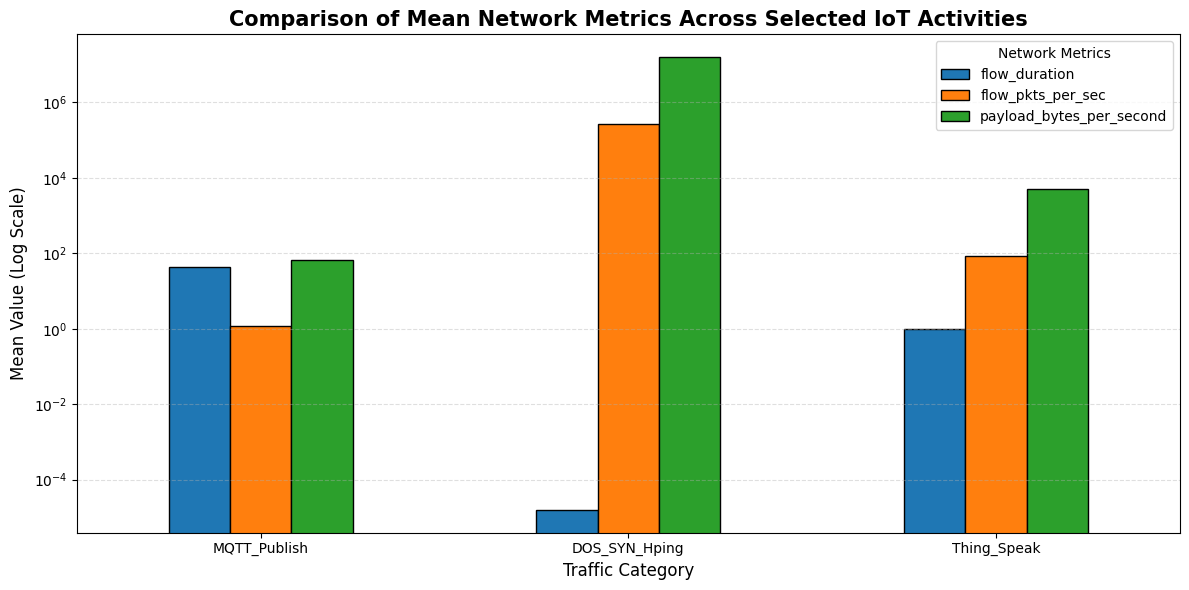

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import io

# ======================================================
# Load the original dataset (corrected header)
# ======================================================

with open("original_RT_IoT2022.csv", "r", encoding="utf-8") as f:
    text = f.read()

text = text.replace('"', '')

lines = text.splitlines()

if lines[0].startswith(","):
    lines[0] = lines[0][1:]

text = "\n".join(lines)

df_plot = pd.read_csv(io.StringIO(text))

# ======================================================
# Remove unnecessary columns
# ======================================================

cols_to_drop = [
    "Unnamed: 0",
    "Flow_ID",
    "Source_IP",
    "Destination_IP",
    "Timestamp",
    "id.orig_p",
    "id.resp_p"
]

df_plot = df_plot.drop(
    columns=[c for c in cols_to_drop if c in df_plot.columns]
)

# ======================================================
# Remove duplicate flows
# ======================================================

feature_cols = [c for c in df_plot.columns if c != "Attack_type"]

df_plot = df_plot.drop_duplicates(
    subset=feature_cols
)

# ======================================================
# Metrics for comparison
# ======================================================

metrics = [
    "flow_duration",
    "flow_pkts_per_sec",
    "payload_bytes_per_second"
]

comparison_df = (
    df_plot
    .groupby("Attack_type")[metrics]
    .mean()
    .loc[
        [
            "MQTT_Publish",
            "DOS_SYN_Hping",
            "Thing_Speak"
        ]
    ]
)

# ======================================================
# Plot
# ======================================================

comparison_df.plot(
    kind="bar",
    figsize=(12,6),
    logy=True,
    edgecolor="black"
)

plt.title(
    "Comparison of Mean Network Metrics Across Selected IoT Activities",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Traffic Category", fontsize=12)
plt.ylabel("Mean Value (Log Scale)", fontsize=12)

plt.xticks(rotation=0)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.legend(title="Network Metrics")

plt.tight_layout()

plt.show()

In [33]:
import pandas as pd
import numpy as np
import time

# ==========================================================
# REAL-TIME LIGHTWEIGHT IDPS
# ==========================================================

def detect_and_explain(raw_flow,
                       model_input,
                       model,
                       baseline,
                       actual_label):

    start = time.time()

    prediction = model.predict(model_input)[0]

    inference_time = (time.time() - start) * 1000

    print("="*70)

    if prediction == 1:

        print("🚨 DETECTION RESULT : ATTACK DETECTED")
        print(f"Attack Type        : {actual_label}")

    else:

        print("✅ DETECTION RESULT : NORMAL")
        print(f"Activity Type      : {actual_label}")

    print(f"Inference Time     : {inference_time:.4f} ms")

    print("\nKey Abnormal Network Features:")

    irregularities = []

    for feature in raw_flow.index:

        current = raw_flow[feature]
        normal = baseline[feature]

        if normal != 0:
            deviation = abs(current-normal)/abs(normal)
        else:
            deviation = abs(current)

        irregularities.append((feature,current,normal,deviation))

    irregularities.sort(key=lambda x:x[3],reverse=True)

    for feat,curr,norm,dev in irregularities[:3]:

        print(f" • {feat}")
        print(f"      Current : {curr:.4f}")
        print(f"      Normal  : {norm:.4f}")

    print("="*70)

In [34]:
#############################################################
# CREATE TEST DATA
#############################################################

test_df = X_test.copy()
test_df["Target"] = y_test.values

#############################################################
# NORMAL BASELINE
#############################################################

normal_baseline = (
    test_df[test_df["Target"] == 0]
    .drop(columns=["Target"])
    .mean()
)

#############################################################
# SELECT 7 NORMAL + 7 ATTACK FLOWS (extra margin so we still
# clearly have 5+ even if any edge-case sample is skipped)
#############################################################

normal_samples = (
    test_df[test_df["Target"] == 0]
    .sample(7, random_state=42)
)

attack_samples = (
    test_df[test_df["Target"] == 1]
    .sample(7, random_state=42)
)

demo_samples = pd.concat(
    [normal_samples, attack_samples]
).sample(frac=1, random_state=42)

#############################################################
# CHECK SAMPLES
#############################################################

print("Normal Samples Selected :", len(normal_samples))
print("Attack Samples Selected :", len(attack_samples))
print("Total Demo Flows        :", len(demo_samples))

#############################################################
# UPDATED detect_and_explain -- takes a DataFrame row (not a
# raw numpy array) so column names/order/dtypes always match
# exactly what the model was trained on. Also hardened against
# divide-by-zero / NaN / inf in the deviation calculation.
#############################################################

def detect_and_explain(raw_flow_df, model, baseline, actual_label):
    start = time.time()
    prediction = model.predict(raw_flow_df)[0]
    inference_time = (time.time() - start) * 1000

    print("=" * 70)

    if prediction == 1:
        print("\U0001F6A8 DETECTION RESULT : ATTACK DETECTED")
        print(f"Attack Type        : {actual_label}")
    else:
        print("\u2705 DETECTION RESULT : NORMAL")
        print(f"Activity Type      : {actual_label}")

    print(f"Inference Time     : {inference_time:.4f} ms")
    print("\nKey Abnormal Network Features:")

    raw_flow = raw_flow_df.iloc[0]
    irregularities = []

    for feature in raw_flow.index:
        current = float(raw_flow[feature])
        normal = float(baseline[feature])

        if normal != 0 and np.isfinite(normal):
            deviation = abs(current - normal) / abs(normal)
        else:
            deviation = abs(current)

        if not np.isfinite(deviation):
            deviation = 0.0

        irregularities.append((feature, current, normal, deviation))

    irregularities.sort(key=lambda x: x[3], reverse=True)

    for feat, curr, norm, dev in irregularities[:3]:
        print(f" \u2022 {feat}")
        print(f"      Current : {curr:.4f}")
        print(f"      Normal  : {norm:.4f}")

    print("=" * 70)
    return prediction

#############################################################
# START IDPS
#############################################################

print("\n")
print("=" * 80)
print("        LIGHTWEIGHT REAL-TIME IoT IDPS")
print("=" * 80)
print(f"Selected Detection Engine : {best_model_name}")
print(f"Deployment Score          : {selection.iloc[0]['DeploymentScore']:.4f}")
print("Status                    : Monitoring Network Traffic")
print("=" * 80)

#############################################################
# WARM-UP CALL (excludes first-call JIT/init overhead from
# the reported per-flow inference times below)
#############################################################

_warmup_flow = demo_samples.drop(columns=["Target"]).iloc[[0]]
if best_model_name == "SVM":
    _warmup_input = pd.DataFrame(
        scaler.transform(_warmup_flow), columns=_warmup_flow.columns
    )
else:
    _warmup_input = _warmup_flow
_ = best_model.predict(_warmup_input)

#############################################################
# REAL-TIME SCANNING
#############################################################

successful_flows = 0

for i, (idx, row) in enumerate(demo_samples.iterrows()):

    print(f"\n================ FLOW {i+1} OF {len(demo_samples)} ================")

    actual_label = "Attack" if row["Target"] == 1 else "Normal"

    # Keep as a single-row DataFrame -- preserves exact column
    # names/order/dtypes the model was trained on, avoids the
    # sklearn "X does not have valid feature names" warning,
    # and avoids any silent numpy dtype-coercion issues.
    raw_flow_df = row.drop("Target").to_frame().T

    if best_model_name == "SVM":
        model_input = pd.DataFrame(
            scaler.transform(raw_flow_df), columns=raw_flow_df.columns
        )
    else:
        model_input = raw_flow_df

    try:
        detect_and_explain(
            raw_flow_df=model_input,
            model=best_model,
            baseline=normal_baseline,
            actual_label=actual_label
        )
        print(f"FLOW {i+1} Completed Successfully")
        successful_flows += 1

    except Exception as e:
        import traceback
        print(f"ERROR in FLOW {i+1}")
        traceback.print_exc()

#############################################################
# END
#############################################################

print("\n")
print("=" * 80)
print(f"Monitoring Completed -- {successful_flows}/{len(demo_samples)} flows processed successfully")
print("=" * 80)

Normal Samples Selected : 7
Attack Samples Selected : 7
Total Demo Flows        : 14


        LIGHTWEIGHT REAL-TIME IoT IDPS
Selected Detection Engine : LightGBM
Deployment Score          : 0.9814
Status                    : Monitoring Network Traffic

================ FLOW 1 OF 14 ================
🚨 DETECTION RESULT : ATTACK DETECTED
Attack Type        : Attack
Inference Time     : 3.9897 ms

Key Abnormal Network Features:
 • bwd_pkts_payload.min
      Current : 72.0000
      Normal  : 15.1463
 • fwd_pkts_payload.min
      Current : 56.0000
      Normal  : 12.9210
 • flow_pkts_payload.min
      Current : 56.0000
      Normal  : 13.2872
FLOW 1 Completed Successfully

================ FLOW 2 OF 14 ================
🚨 DETECTION RESULT : ATTACK DETECTED
Attack Type        : Attack
Inference Time     : 5.0290 ms

Key Abnormal Network Features:
 • fwd_pkts_payload.min
      Current : 41.0000
      Normal  : 12.9210
 • flow_pkts_payload.min
      Current : 41.0000
      Normal  : 13.2872
 • 